In [39]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TENSORFLOW_AVAILABLE = True
    tf.random.set_seed(RANDOM_STATE)
except ImportError:
    TENSORFLOW_AVAILABLE = False


DATA_DIR = "content"
PLANT = 1
TARGET_COL = "AC_POWER"
TEST_FRACTION = 0.20      # last 20%
LSTM_WINDOW = 8            # number of past 15-min steps (2 hours) the LSTM sees before predicting the next step
N_CV_SPLITS = 5
N_SEARCH_ITER = 15          # candidate settings tried by RandomizedSearchCV per model


## 2. Data Loading

`load_plant_data()` loads the **real** Kaggle CSVs and merges the per-inverter generation data with the plant-level weather sensor data on `DATE_TIME`. Generation is summed across inverters so that the target represents total plant AC power output at each timestamp, matching the aggregation described in the dataset comparison document.


In [27]:
def load_plant_data(plant: int = PLANT, data_dir: str = DATA_DIR) -> pd.DataFrame:

    gen_path = os.path.join(data_dir, f"Plant_{plant}_Generation_Data.csv")
    weather_path = os.path.join(data_dir, f"Plant_{plant}_Weather_Sensor_Data.csv")


    print(f"Loading REAL dataset files for Plant {plant} from '{data_dir}/'")
    generation = pd.read_csv(gen_path)
    weather = pd.read_csv(weather_path)
    generation["DATE_TIME"] = pd.to_datetime(generation["DATE_TIME"], dayfirst=True, errors="coerce")
    weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"], dayfirst=True, errors="coerce")

    # Aggregate generation across inverters -> one row per timestamp (plant-level total output)
    gen_agg = (generation
               .groupby("DATE_TIME", as_index=False)
               .agg(DC_POWER=("DC_POWER", "sum"), AC_POWER=("AC_POWER", "sum")))

    weather_cols = weather[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]]

    merged = pd.merge(gen_agg, weather_cols, on="DATE_TIME", how="inner").sort_values("DATE_TIME")
    merged = merged.set_index("DATE_TIME")
    merged = merged[~merged.index.duplicated(keep="first")]  # guard against duplicate timestamps
    return merged


df = load_plant_data(data_dir="")
print("Shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
df.head()


Loading REAL dataset files for Plant 1 from '/'
Shape: (3157, 5)
Date range: 2020-05-15 00:00:00 to 2020-06-17 23:45:00


,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,,
2020-05-15 00:00:00,0.0,0.0,25.184316,22.857507,0.0
2020-05-15 00:15:00,0.0,0.0,25.084589,22.761668,0.0
2020-05-15 00:30:00,0.0,0.0,24.935753,22.592306,0.0
2020-05-15 00:45:00,0.0,0.0,24.846130,22.360852,0.0
2020-05-15 01:00:00,0.0,0.0,24.621525,22.165423,0.0


## 3. Exploratory Data Analysis (EDA)

Before any modelling, we look at the data itself. This matters for renewable-energy forecasting specifically because (a) sensor data commonly has short dropout gaps that must be understood before choosing an imputation strategy, (b) solar power is **zero-inflated** (every night-time reading is exactly zero), which affects both metric interpretation and model behaviour, and (c) the literature review identified irradiance and temperature as the dominant predictors — the correlation analysis below checks whether that holds for this specific plant.

Missing values per column:
 DC_POWER               0
AC_POWER               0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64


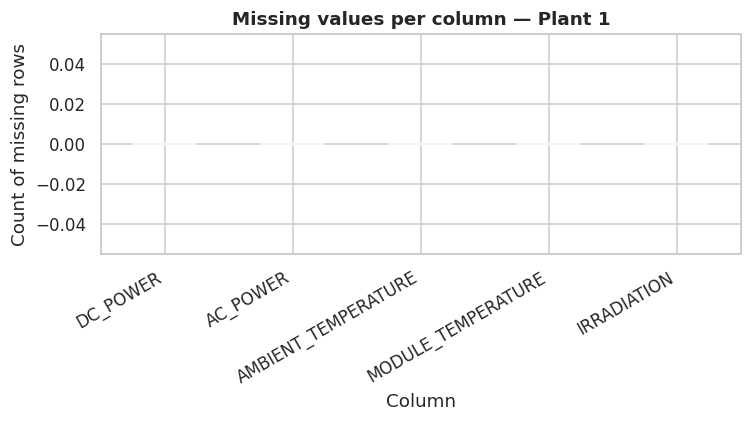


Summary statistics:


,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000
mean,68560.019625,6704.830534,25.560257,31.175453,0.230103
std,88055.843520,8604.217954,3.351059,12.272685,0.301348
min,0.000000,0.000000,20.398505,18.140415,0.000000
25%,0.000000,0.000000,22.739895,21.130249,0.000000
50%,8430.196429,814.880357,24.680324,24.801971,0.027748
75%,140409.892856,13752.112500,27.941221,41.449481,0.451576
max,298937.785710,29150.212499,35.252486,65.545714,1.221652


In [48]:
#  3.1 Missing values
missing = df.isna().sum()
print("Missing values per column:\n", missing)

fig, ax = plt.subplots(figsize=(7, 4))
missing.plot(kind="bar", ax=ax, color="indianred")
ax.set_title(f"Missing values per column — Plant {PLANT}")
ax.set_ylabel("Count of missing rows")
ax.set_xlabel("Column")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("\nSummary statistics:")
display(df.describe())

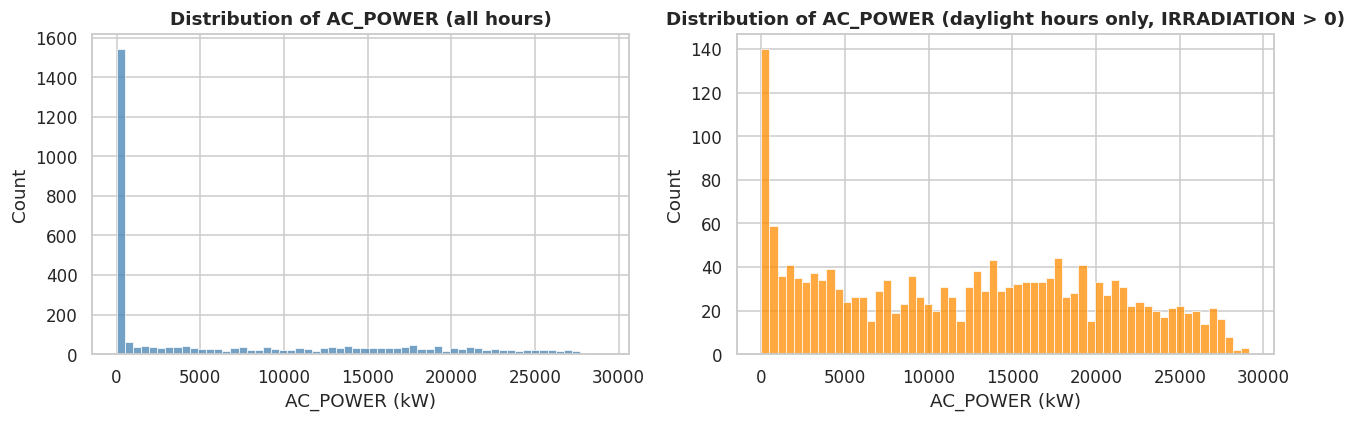

Share of all timestamps with AC_POWER == 0 (night-time): 46.6%


In [29]:
# 3.2 Target distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[TARGET_COL], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title(f"Distribution of {TARGET_COL} (all hours)")
axes[0].set_xlabel(f"{TARGET_COL} (kW)")

daylight_mask = df["IRRADIATION"] > 0
sns.histplot(df.loc[daylight_mask, TARGET_COL], bins=60, ax=axes[1], color="darkorange")
axes[1].set_title(f"Distribution of {TARGET_COL} (daylight hours only, IRRADIATION > 0)")
axes[1].set_xlabel(f"{TARGET_COL} (kW)")
plt.tight_layout()
plt.show()

zero_share = (df[TARGET_COL] == 0).mean()
print(f"Share of all timestamps with {TARGET_COL} == 0 (night-time): {zero_share:.1%}")


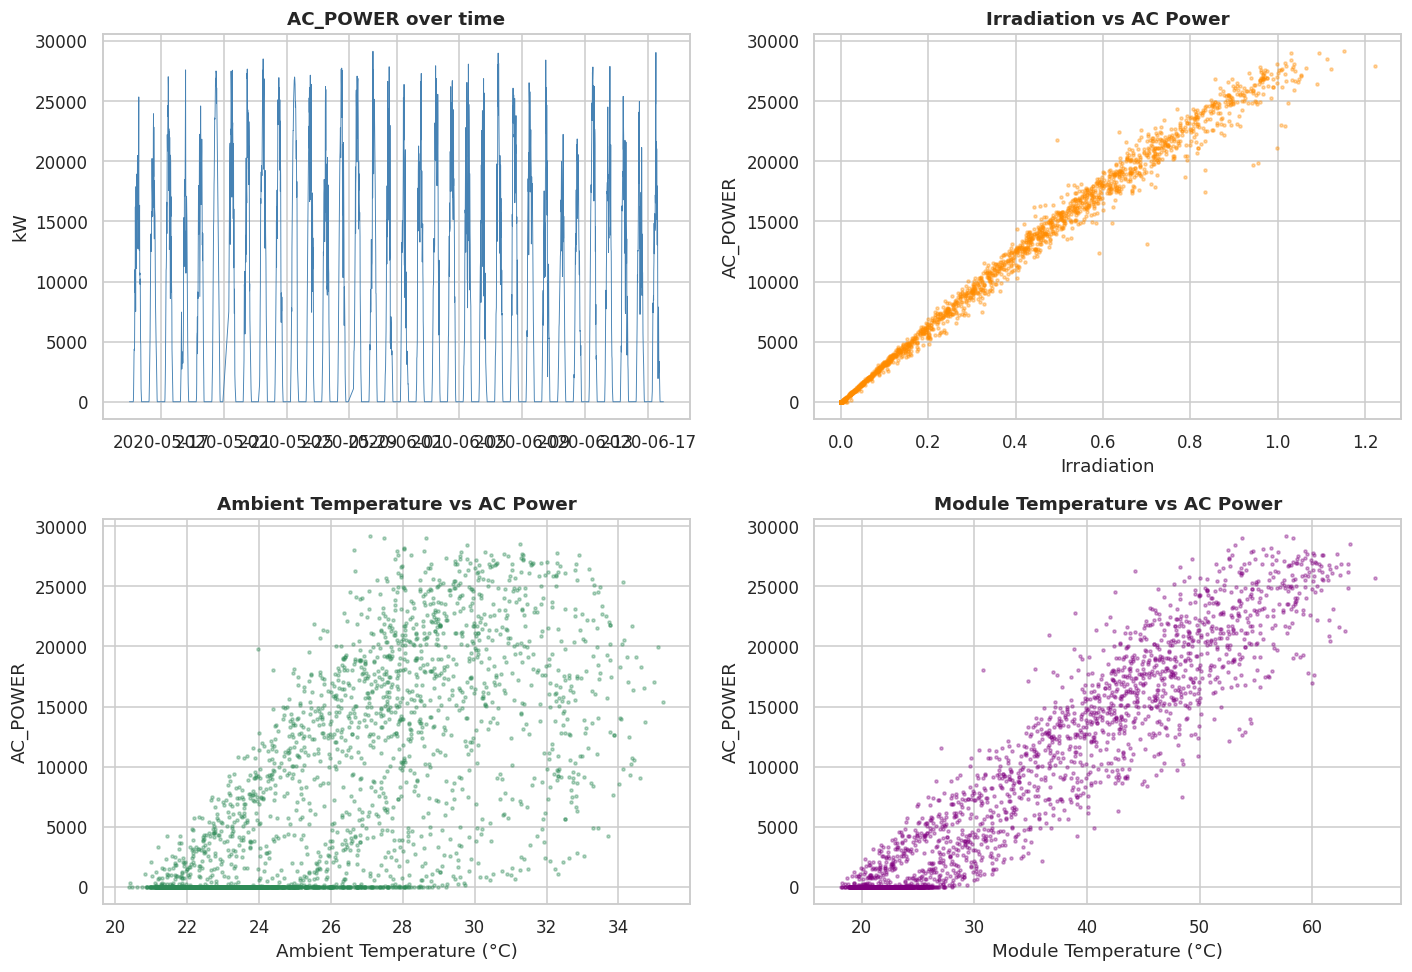

In [30]:
# 3.3 Time series overview & bivariate relationships
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(df.index, df[TARGET_COL], linewidth=0.6, color="steelblue")
axes[0, 0].set_title(f"{TARGET_COL} over time")
axes[0, 0].set_ylabel("kW")

axes[0, 1].scatter(df["IRRADIATION"], df[TARGET_COL], s=4, alpha=0.35, color="darkorange")
axes[0, 1].set_xlabel("Irradiation")
axes[0, 1].set_ylabel(TARGET_COL)
axes[0, 1].set_title("Irradiation vs AC Power")

axes[1, 0].scatter(df["AMBIENT_TEMPERATURE"], df[TARGET_COL], s=4, alpha=0.35, color="seagreen")
axes[1, 0].set_xlabel("Ambient Temperature (°C)")
axes[1, 0].set_ylabel(TARGET_COL)
axes[1, 0].set_title("Ambient Temperature vs AC Power")

axes[1, 1].scatter(df["MODULE_TEMPERATURE"], df[TARGET_COL], s=4, alpha=0.35, color="purple")
axes[1, 1].set_xlabel("Module Temperature (°C)")
axes[1, 1].set_ylabel(TARGET_COL)
axes[1, 1].set_title("Module Temperature vs AC Power")

plt.tight_layout()
plt.show()


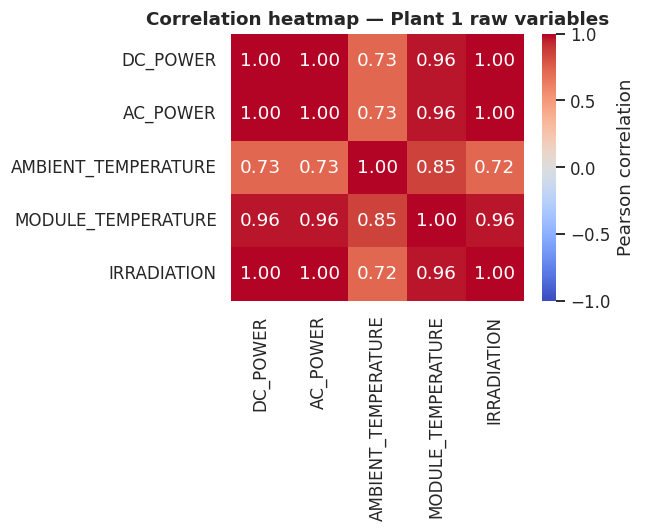

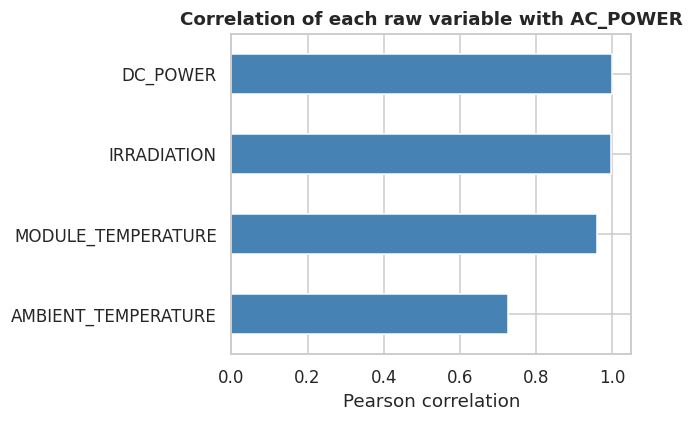

Correlation with target (AC_POWER), sorted:
DC_POWER               0.999997
IRRADIATION            0.995864
MODULE_TEMPERATURE     0.961011
AMBIENT_TEMPERATURE    0.725879
Name: AC_POWER, dtype: float64


In [31]:
# 3.4 Correlation heatmap & correlation with target
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title(f"Correlation heatmap — Plant {PLANT} raw variables")
plt.tight_layout()
plt.show()

target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
target_corr.plot(kind="barh", ax=ax, color=["indianred" if v < 0 else "steelblue" for v in target_corr])
ax.set_title(f"Correlation of each raw variable with {TARGET_COL}")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

print("Correlation with target (AC_POWER), sorted:")
print(target_corr.sort_values(ascending=False))


## 4. Preprocessing & Feature Engineering



In [32]:
def preprocess(data: pd.DataFrame) -> pd.DataFrame:

    out = data.copy()

    #  1. Missing values: forward-fill only (causal, no look-ahead)
    weather_cols_ = ["AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]
    out[weather_cols_] = out[weather_cols_].ffill()

    # 2. Clip sensor noise
    out["AC_POWER"] = out["AC_POWER"].clip(lower=0)
    out["DC_POWER"] = out["DC_POWER"].clip(lower=0)

    #  3. Calendar features
    out["hour"] = out.index.hour
    out["dayofweek"] = out.index.dayofweek
    out["month"] = out.index.month

    #  4. Cyclical encoding of hour-of-day (captures sunrise/sunset continuity)
    out["hour_sin"] = np.sin(2 * np.pi * (out.index.hour + out.index.minute / 60.0) / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * (out.index.hour + out.index.minute / 60.0) / 24.0)

    # 5. Lag features (recent temporal context for non-sequence models)
    periods_per_day = int(24 * 60 / 15)  # 96 for 15-minute data
    for lag in [1, 2, 4]:  # 15, 30, 60 minutes back
        out[f"AC_POWER_lag{lag}"] = out["AC_POWER"].shift(lag)
        out[f"IRRADIATION_lag{lag}"] = out["IRRADIATION"].shift(lag)
    out[f"AC_POWER_lag{periods_per_day}"] = out["AC_POWER"].shift(periods_per_day)  # same time, previous day

    #  6. Rolling statistics of IRRADIATION, shifted so the current row is never included
    out["IRRADIATION_roll_mean_1h"] = out["IRRADIATION"].shift(1).rolling(4).mean()
    out["IRRADIATION_roll_std_1h"] = out["IRRADIATION"].shift(1).rolling(4).std()
    out["IRRADIATION_roll_mean_1d"] = out["IRRADIATION"].shift(1).rolling(periods_per_day).mean()

    out = out.dropna()
    return out


processed = preprocess(df)
feature_cols = [c for c in processed.columns if c not in ("AC_POWER", "DC_POWER")]
print(f"Rows after feature engineering / dropna: {len(processed)} (from {len(df)} raw rows)")
print(f"\nFeatures used ({len(feature_cols)}):")
print(feature_cols)
processed.head()


Rows after feature engineering / dropna: 3061 (from 3157 raw rows)

Features used (18):
['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'AC_POWER_lag1', 'IRRADIATION_lag1', 'AC_POWER_lag2', 'IRRADIATION_lag2', 'AC_POWER_lag4', 'IRRADIATION_lag4', 'AC_POWER_lag96', 'IRRADIATION_roll_mean_1h', 'IRRADIATION_roll_std_1h', 'IRRADIATION_roll_mean_1d']


,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour,dayofweek,month,hour_sin,hour_cos,AC_POWER_lag1,IRRADIATION_lag1,AC_POWER_lag2,IRRADIATION_lag2,AC_POWER_lag4,IRRADIATION_lag4,AC_POWER_lag96,IRRADIATION_roll_mean_1h,IRRADIATION_roll_std_1h,IRRADIATION_roll_mean_1d
DATE_TIME,,,,,,,,,,,,,,,,,,,,
2020-05-16 02:45:00,0.0,0.0,21.496287,19.624870,0.0,2,5,5,0.659346,0.751840,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.198302
2020-05-16 03:00:00,0.0,0.0,21.645913,20.065206,0.0,3,5,5,0.707107,0.707107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.198302
2020-05-16 03:15:00,0.0,0.0,21.674314,20.112160,0.0,3,5,5,0.751840,0.659346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.198302
2020-05-16 03:30:00,0.0,0.0,21.731421,20.351884,0.0,3,5,5,0.793353,0.608761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.198302
2020-05-16 03:45:00,0.0,0.0,21.780166,20.505894,0.0,3,5,5,0.831470,0.555570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.198302


## 5. Time-Aware Train/Test Split

Because this is a time series, the split is **chronological** — the first 80% of the timeline is used for training and the last 20% for testing — never a random shuffle. A random split would let the model train on timestamps that occur *after* some test timestamps, which is a data-leakage error specific to time-series problems: at prediction time in the real world, the model would never have seen the future. The same chronological ordering is respected again in Section 7 when tuning hyperparameters (`TimeSeriesSplit`, not `KFold`).

In [33]:
split_idx = int(len(processed) * (1 - TEST_FRACTION))
train_df = processed.iloc[:split_idx]
test_df = processed.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[TARGET_COL]
X_test, y_test = test_df[feature_cols], test_df[TARGET_COL]

print(f"Train period: {train_df.index.min()}  ->  {train_df.index.max()}  ({len(train_df)} rows)")
print(f"Test period:  {test_df.index.min()}  ->  {test_df.index.max()}  ({len(test_df)} rows)")
assert train_df.index.max() < test_df.index.min(), "Train/test overlap detected — check the split!"


Train period: 2020-05-16 02:45:00  ->  2020-06-11 14:00:00  (2448 rows)
Test period:  2020-06-11 14:15:00  ->  2020-06-17 23:45:00  (613 rows)


## 6. Feature Scaling

`MinMaxScaler` is **fit on the training features only**, then used to *transform* both the training and test features. Fitting the scaler on the full dataset (train + test combined) — a very common student mistake — would leak the min/max range of the test period into training, so the model would implicitly know something about the scale of future data it should not have access to. Tree-based models (Random Forest, XGBoost) do not need scaled inputs and are trained on the raw features; the scaled features are only used for Linear Regression and the LSTM, which are scale-sensitive.

In [34]:
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print("Scaler fitted on TRAIN ONLY. Train feature range after scaling (should be ~[0, 1]):")
print(X_train_scaled.describe().loc[["min", "max"]].T.head())
print("\nTest feature range after scaling (can fall outside [0, 1] — that is expected and correct, "
      "since the scaler never saw the test data's own min/max):")
print(X_test_scaled.describe().loc[["min", "max"]].T.head())


Scaler fitted on TRAIN ONLY. Train feature range after scaling (should be ~[0, 1]):
                     min  max
AMBIENT_TEMPERATURE  0.0  1.0
MODULE_TEMPERATURE   0.0  1.0
IRRADIATION          0.0  1.0
hour                 0.0  1.0
dayofweek            0.0  1.0

Test feature range after scaling (can fall outside [0, 1] — that is expected and correct, since the scaler never saw the test data's own min/max):
                          min       max
AMBIENT_TEMPERATURE  0.023751  0.646874
MODULE_TEMPERATURE   0.007412  0.870064
IRRADIATION          0.000000  1.061289
hour                 0.000000  1.000000
dayofweek            0.000000  1.000000


## 7. Model Training & Hyperparameter Tuning

Four model families are compared, matching the research plan: a linear baseline, two tree-based ensembles, and (in Section 8) a deep sequence model. Random Forest and XGBoost are tuned with `RandomizedSearchCV` using **`TimeSeriesSplit`** (not the default random `KFold`) as the cross-validation strategy — every validation fold is later in time than the training fold it is scored against, so hyperparameter selection itself does not leak future information. The search is performed only on `X_train`/`y_train`; the test set is touched exactly once, at the very end, for the final evaluation in Section 9.

In [35]:
def evaluate(y_true, y_pred, model_name: str) -> dict:

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}


results = []
predictions = {}
fitted_models = {}
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

# Model 1: Linear Regression (baseline, no hyperparameters to tune)
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
pred_lin = lin_model.predict(X_test_scaled)
predictions["Linear Regression"] = pred_lin
fitted_models["Linear Regression"] = lin_model
results.append(evaluate(y_test, pred_lin, "Linear Regression"))
print("Linear Regression trained.")


Linear Regression trained.


In [36]:
# Model 2: Random Forest (tuned with TimeSeriesSplit)
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=N_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
print("Best Random Forest params:", rf_search.best_params_)

pred_rf = rf_model.predict(X_test)
predictions["Random Forest"] = pred_rf
fitted_models["Random Forest"] = rf_model
results.append(evaluate(y_test, pred_rf, "Random Forest"))
print("Random Forest trained and tuned.")


Best Random Forest params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 8}
Random Forest trained and tuned.


In [40]:
# Model 3: XGBoost (tuned with TimeSeriesSplit); falls back to sklearn's
#              GradientBoostingRegressor with the same search space if xgboost is not installed
gb_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.02, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
}

if XGBOOST_AVAILABLE:
    base_gb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    gb_name = "XGBoost"
else:
    base_gb = GradientBoostingRegressor(random_state=RANDOM_STATE)
    gb_name = "Gradient Boosting (sklearn fallback)"
    gb_param_grid.pop("subsample")

gb_search = RandomizedSearchCV(
    base_gb,
    param_distributions=gb_param_grid,
    n_iter=N_SEARCH_ITER,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search.fit(X_train, y_train)
gb_model = gb_search.best_estimator_
print(f"Best {gb_name} params:", gb_search.best_params_)

pred_gb = gb_model.predict(X_test)
predictions[gb_name] = pred_gb
fitted_models[gb_name] = gb_model
results.append(evaluate(y_test, pred_gb, gb_name))
print(f"{gb_name} trained and tuned.")

Best XGBoost params: {'subsample': 0.85, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.02}
XGBoost trained and tuned.


## 8. LSTM Sequence Model

The LSTM sees the last `LSTM_WINDOW` (2 hours of 15-minute readings) of scaled features and predicts the next AC_POWER value, giving it explicit access to short-term temporal structure the way a recurrent architecture is designed to. Two corrections relative to a naive implementation:



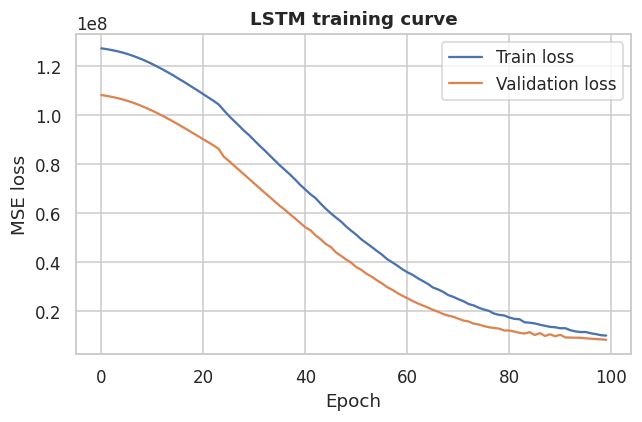

LSTM trained (stopped after 100 epochs) and evaluated.


In [41]:
def make_sequences(X: np.ndarray, y: np.ndarray, window: int):
    '''Convert a features array into overlapping sequences of length `window`
    (each sample = the last `window` timesteps of features -> the next AC_POWER).'''
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i - window:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)


if TENSORFLOW_AVAILABLE:
    W = LSTM_WINDOW

    # Training sequences: purely within the training period.
    X_train_seq, y_train_seq = make_sequences(X_train_scaled.values, y_train.values, W)

    # Test sequences: prepend the last W rows of TRAIN so no test timestamp is wasted and there is
    # no artificial discontinuity at the split boundary
    X_test_input = np.concatenate([X_train_scaled.values[-W:], X_test_scaled.values], axis=0)
    y_test_input = np.concatenate([y_train.values[-W:], y_test.values], axis=0)
    X_test_seq, y_test_seq = make_sequences(X_test_input, y_test_input, W)
    # y_test_seq now lines up one-to-one with y_test
    assert len(y_test_seq) == len(y_test)

    lstm_model = Sequential([
        LSTM(64, input_shape=(W, X_train_scaled.shape[1]), activation="tanh"),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    lstm_model.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    history = lstm_model.fit(
        X_train_seq, y_train_seq,
        epochs=100, batch_size=64,
        validation_split=0.1,
        shuffle=False,
        callbacks=[early_stop],
        verbose=0,
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history.history["loss"], label="Train loss")
    ax.plot(history.history["val_loss"], label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss")
    ax.set_title("LSTM training curve")
    ax.legend()
    plt.tight_layout()
    plt.show()

    pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
    predictions["LSTM"] = pred_lstm
    results.append(evaluate(y_test, pred_lstm, "LSTM"))
    print(f"LSTM trained (stopped after {len(history.history['loss'])} epochs) and evaluated.")
else:
    print("TensorFlow not available in this environment -> LSTM skipped. "
          "Run this notebook on Kaggle/Colab (or `pip install tensorflow`) to include it.")


## 9. Evaluation & Visualisation

All four models are now evaluated against the **same** held-out test period using **MAE, RMSE and R²**. Beyond the summary table, we look at *how* each model is wrong, not just *how much*: actual-vs-predicted plots reveal systematic bias (e.g. under-predicting peaks), and residual plots reveal whether errors are random noise or a structured pattern the model is missing — both are standard diagnostics that a single R² number can hide.

            Model         MAE        RMSE       R2
          XGBoost  248.582668  472.933554 0.996455
    Random Forest  225.552023  474.638914 0.996430
Linear Regression  280.661860  500.204627 0.996035
             LSTM 1313.050588 2587.157738 0.893924


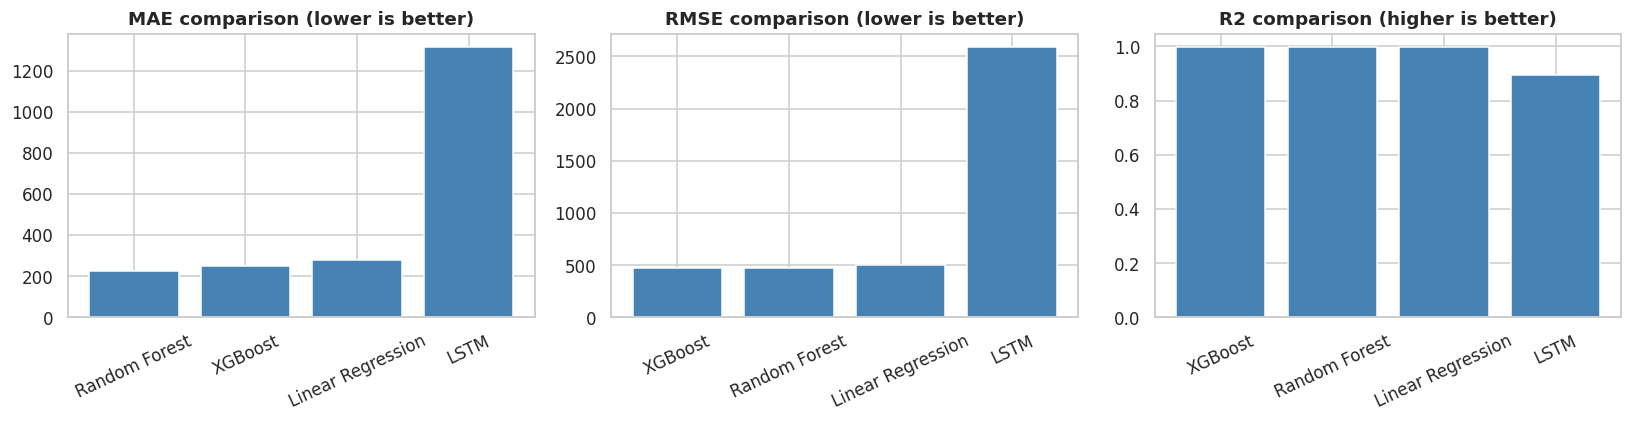

In [42]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, better in zip(axes, ["MAE", "RMSE", "R2"], ["lower", "lower", "higher"]):
    order = results_df.sort_values(metric, ascending=(better == "lower"))
    ax.bar(order["Model"], order[metric], color="steelblue")
    ax.set_title(f"{metric} comparison ({better} is better)")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()


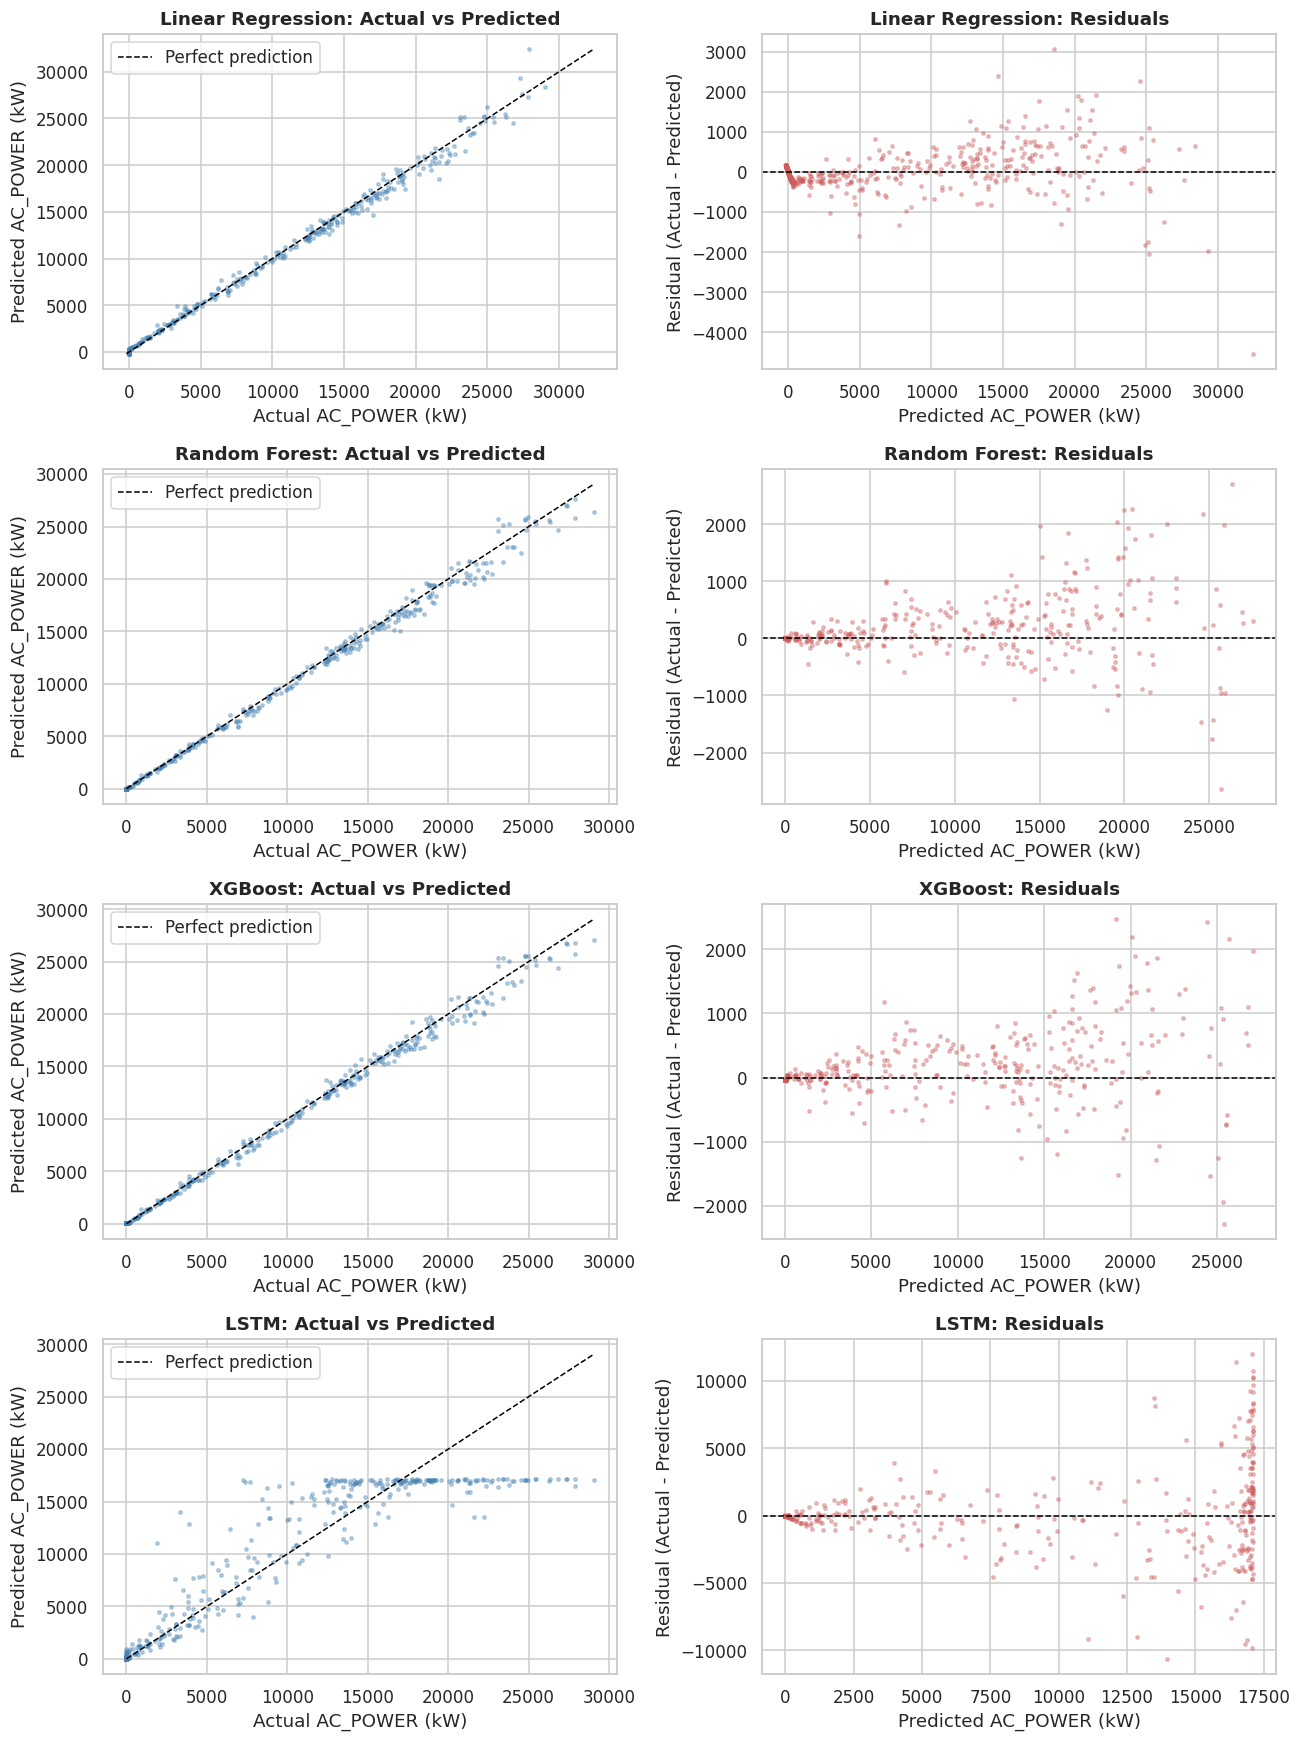

In [43]:
# Actual vs Predicted + Residuals, per model
n_models = len(predictions)
fig, axes = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
if n_models == 1:
    axes = axes.reshape(1, -1)

for row, (name, pred) in enumerate(predictions.items()):
    y_ref = y_test.values
    pred = np.asarray(pred)
    residuals = y_ref - pred

    # Actual vs Predicted scatter
    ax = axes[row, 0]
    ax.scatter(y_ref, pred, s=5, alpha=0.35, color="steelblue")
    lims = [min(y_ref.min(), pred.min()), max(y_ref.max(), pred.max())]
    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
    ax.set_xlabel("Actual AC_POWER (kW)")
    ax.set_ylabel("Predicted AC_POWER (kW)")
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.legend()

    # Residual plot
    ax = axes[row, 1]
    ax.scatter(pred, residuals, s=5, alpha=0.35, color="indianred")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted AC_POWER (kW)")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.set_title(f"{name}: Residuals")

plt.tight_layout()
plt.show()


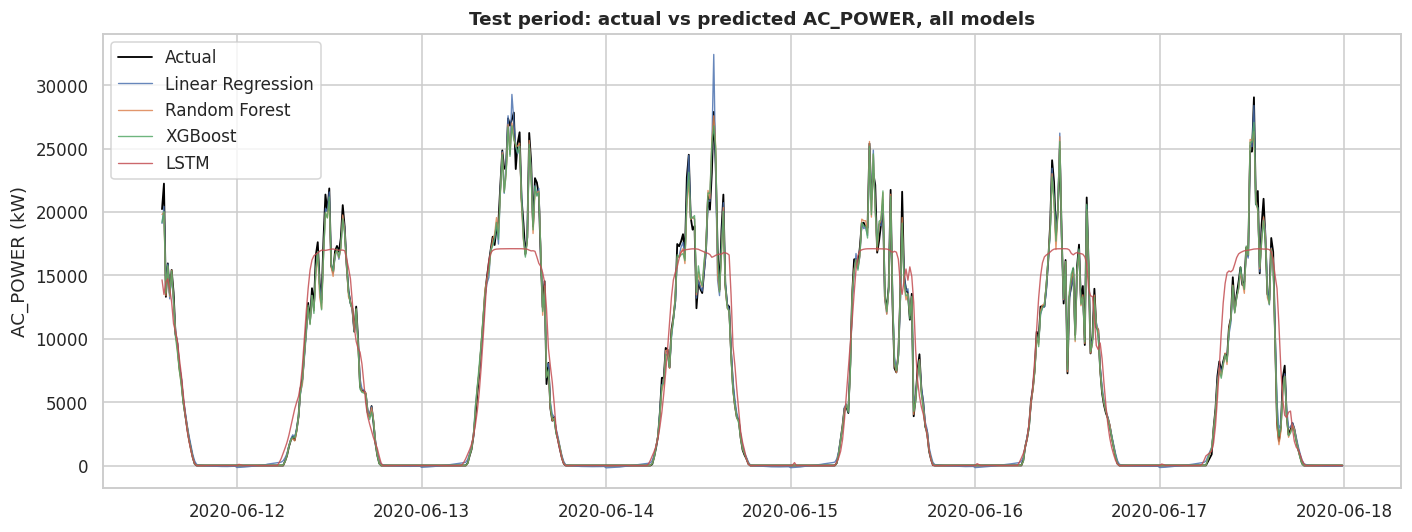

In [44]:
# Time-series view of the test period: actual vs each model's predictions
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_df.index, y_test.values, label="Actual", color="black", linewidth=1.2)
for name, pred in predictions.items():
    ax.plot(test_df.index, np.asarray(pred), label=name, linewidth=0.9, alpha=0.85)
ax.set_ylabel("AC_POWER (kW)")
ax.set_title("Test period: actual vs predicted AC_POWER, all models")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Feature Importance

Feature importance from the tree-based models addresses **RQ1** (which meteorological variables matter most). Random Forest and XGBoost/Gradient Boosting importances are shown separately, since the two algorithms compute importance differently (mean decrease in impurity vs. gain-based importance) and can disagree on the exact ranking of secondary features even when they agree on the dominant one.

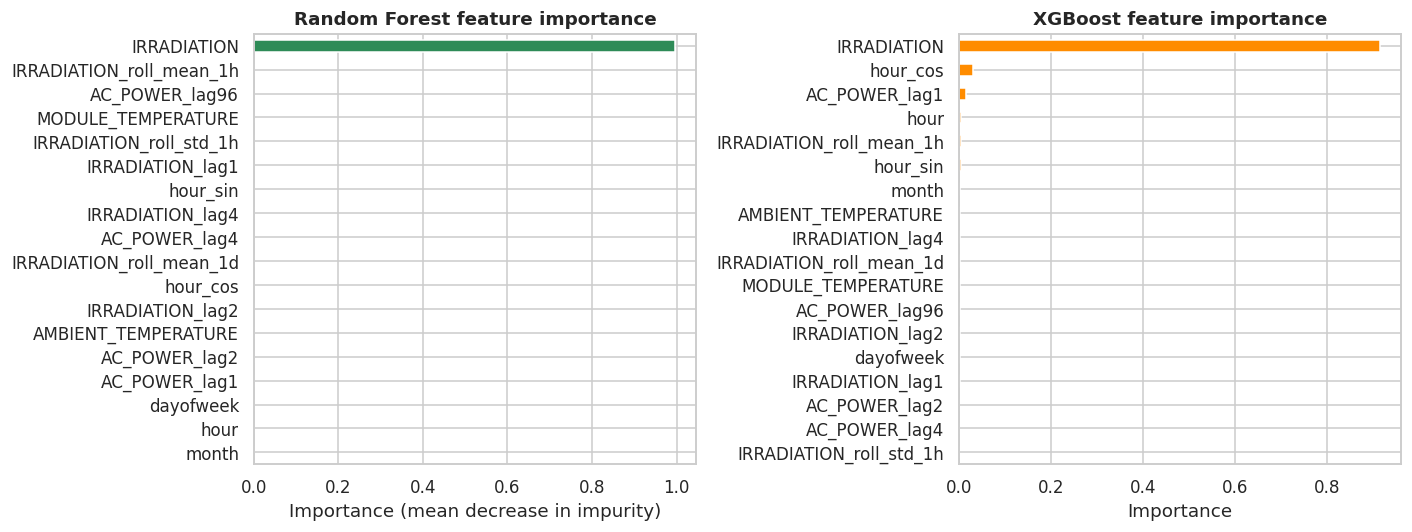

Top 5 features (Random Forest):
IRRADIATION                 0.996703
IRRADIATION_roll_mean_1h    0.000466
AC_POWER_lag96              0.000292
MODULE_TEMPERATURE          0.000278
IRRADIATION_roll_std_1h     0.000269
dtype: float64


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
rf_importances.plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Random Forest feature importance")
axes[0].set_xlabel("Importance (mean decrease in impurity)")

gb_importances = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values()
gb_importances.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title(f"{gb_name} feature importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("Top 5 features (Random Forest):")
print(rf_importances.sort_values(ascending=False).head(5))


## 11. Error Analysis by Weather Regime (RQ3)

Splits the test set into 'clear' (high irradiation) vs. 'cloudy/variable' (low/variable irradiation) halves, using the **test set's own median** irradiation as the threshold, and reports RMSE separately for each. This checks whether the aggregate metrics in Section 9 are hiding regime-specific weaknesses — a gap identified explicitly in the literature review (Aouidad and Bouhelal, 2024 found models that looked strong in aggregate still failed badly on peak/clear-sky output).

            Model  RMSE_clear_sky  RMSE_cloudy_variable  MAE_clear_sky  MAE_cloudy_variable
          XGBoost      667.348960             35.400377     461.325712            35.144386
    Random Forest      670.654436              7.292532     449.212854             1.160274
Linear Regression      697.583686            114.077733     470.092053            90.612614
             LSTM     3653.248947            137.117259    2585.991186            35.950054


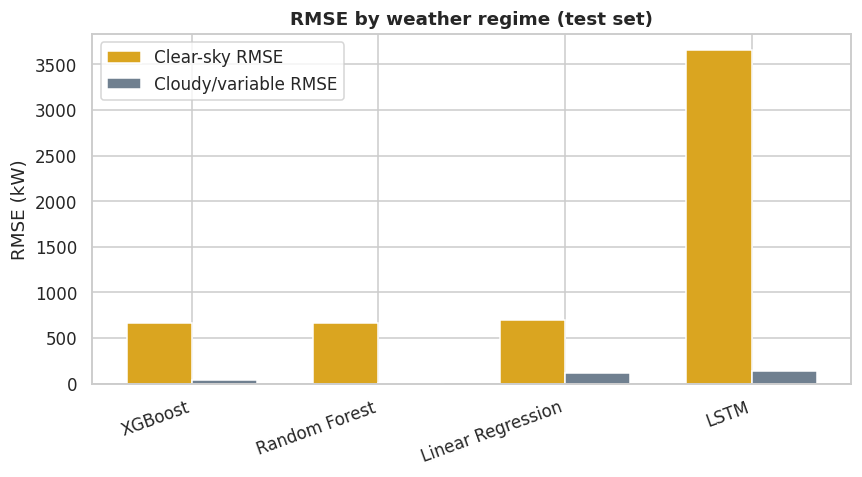

In [46]:
irradiation_median = test_df["IRRADIATION"].median()
clear_mask = (test_df["IRRADIATION"] >= irradiation_median).values
cloudy_mask = ~clear_mask

regime_rows = []
for model_name, pred in predictions.items():
    pred = np.asarray(pred)
    rmse_clear = np.sqrt(mean_squared_error(y_test.values[clear_mask], pred[clear_mask]))
    rmse_cloudy = np.sqrt(mean_squared_error(y_test.values[cloudy_mask], pred[cloudy_mask]))
    mae_clear = mean_absolute_error(y_test.values[clear_mask], pred[clear_mask])
    mae_cloudy = mean_absolute_error(y_test.values[cloudy_mask], pred[cloudy_mask])
    regime_rows.append({
        "Model": model_name,
        "RMSE_clear_sky": rmse_clear, "RMSE_cloudy_variable": rmse_cloudy,
        "MAE_clear_sky": mae_clear, "MAE_cloudy_variable": mae_cloudy,
    })

regime_df = pd.DataFrame(regime_rows).sort_values("RMSE_clear_sky")
print(regime_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(regime_df))
width = 0.35
ax.bar(x - width / 2, regime_df["RMSE_clear_sky"], width, label="Clear-sky RMSE", color="goldenrod")
ax.bar(x + width / 2, regime_df["RMSE_cloudy_variable"], width, label="Cloudy/variable RMSE", color="slategray")
ax.set_xticks(x)
ax.set_xticklabels(regime_df["Model"], rotation=20, ha="right")
ax.set_ylabel("RMSE (kW)")
ax.set_title("RMSE by weather regime (test set)")
ax.legend()
plt.tight_layout()
plt.show()


## 12. Results Summary, Discussion, Limitations, Future Work, Conclusion


In [47]:
best_row = results_df.iloc[0]
top_feature = rf_importances.sort_values(ascending=False).index[0]
regime_gap = (regime_df.set_index("Model")["RMSE_cloudy_variable"]
              - regime_df.set_index("Model")["RMSE_clear_sky"])
harder_regime = "cloudy/variable" if regime_gap.mean() > 0 else "clear-sky"

print("=" * 70)
print("AUTO-GENERATED RESULTS SUMMARY (from this run's actual computed values)")
print("=" * 70)
print(f"Best-performing model overall (lowest RMSE): {best_row['Model']}")
print(f"  MAE  = {best_row['MAE']:.4f} kW")
print(f"  RMSE = {best_row['RMSE']:.4f} kW")
print(f"  R2   = {best_row['R2']:.4f}")
print(f"Most important feature (Random Forest): {top_feature}")
print(f"Regime where models struggle more on average: {harder_regime}")
print("\nFull comparison table:")
display(results_df)
print("\nRegime error breakdown:")
display(regime_df)


AUTO-GENERATED RESULTS SUMMARY (from this run's actual computed values)
Best-performing model overall (lowest RMSE): XGBoost
  MAE  = 248.5827 kW
  RMSE = 472.9336 kW
  R2   = 0.9965
Most important feature (Random Forest): IRRADIATION
Regime where models struggle more on average: clear-sky

Full comparison table:


,Model,MAE,RMSE,R2
0,XGBoost,248.582668,472.933554,0.996455
1,Random Forest,225.552023,474.638914,0.996430
2,Linear Regression,280.661860,500.204627,0.996035
3,LSTM,1313.050588,2587.157738,0.893924



Regime error breakdown:


,Model,RMSE_clear_sky,RMSE_cloudy_variable,MAE_clear_sky,MAE_cloudy_variable
2,XGBoost,667.348960,35.400377,461.325712,35.144386
1,Random Forest,670.654436,7.292532,449.212854,1.160274
0,Linear Regression,697.583686,114.077733,470.092053,90.612614
3,LSTM,3653.248947,137.117259,2585.991186,35.950054
